# Lab Segmentation 2

In [ ]:
from commonfunctions import *
import numpy as np
from skimage import io
%matplotlib inline
%load_ext autoreload
%autoreload 2

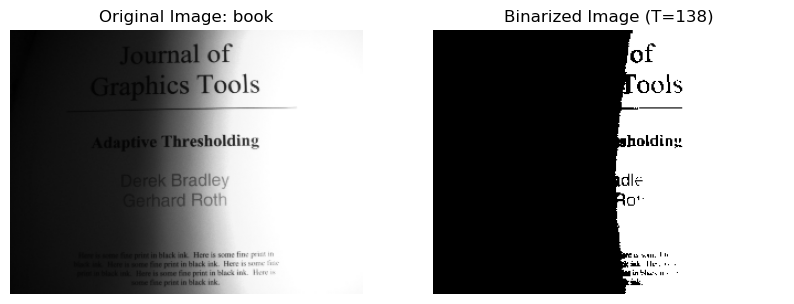

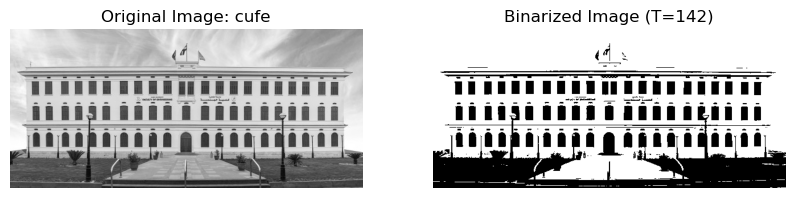

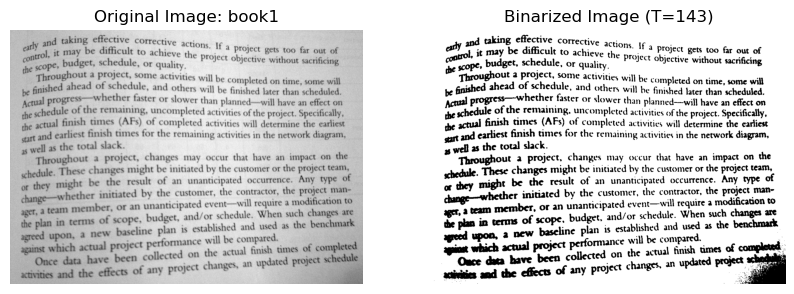

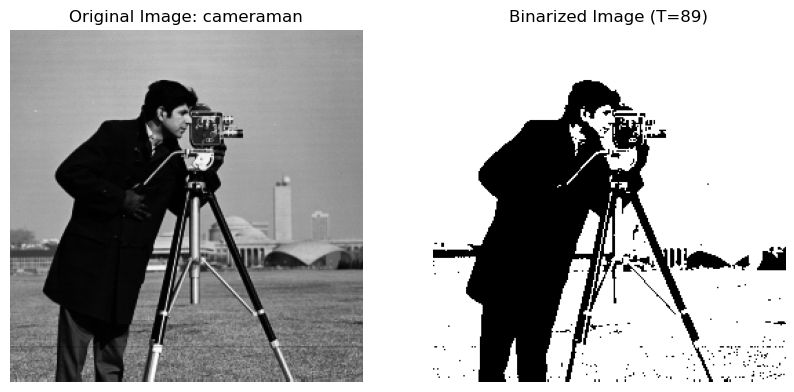

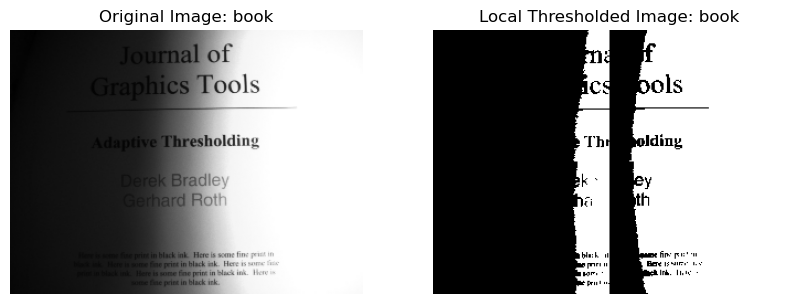

240 320


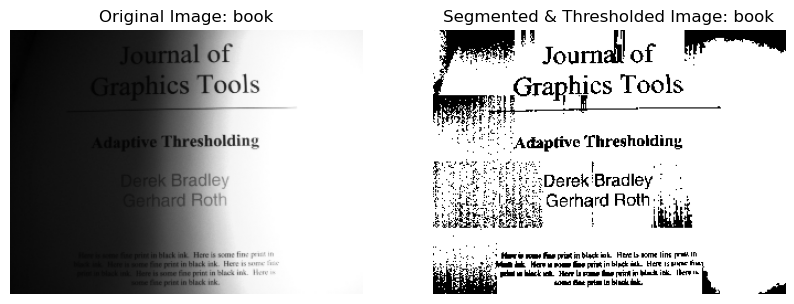

In [ ]:


def compute_histogram(image):
    """Compute histogram manually (0 - 255)."""
    hist = np.zeros(256)
    for pixel in image.flatten():
        hist[pixel] += 1
    return hist

def getThreshold(image):
    """Adaptive global threshold using iterative method."""
    # 1- Convert to uint8
    if image.dtype != 'uint8':
       image = (image * 255).astype('uint8') 
    
    # 2- Compute histogram
    hist = compute_histogram(image)
    
    # 3- Compute initial threshold (T_init): Weighted mean
    pixel_values = np.arange(256)
    total_pixels = np.sum(hist)
    T = round(np.sum(pixel_values * hist) / total_pixels)

    prev_T = -1

    # 4- Repeat until threshold stabilizes
    while T != prev_T:
        prev_T = T

        # Pixels below threshold
        lower = pixel_values[:T]
        lower_hist = hist[:T]
        mean_low = np.sum(lower * lower_hist) / np.sum(lower_hist) if np.sum(lower_hist) > 0 else 0

        # Pixels above threshold
        upper = pixel_values[T+1:]
        upper_hist = hist[T+1:]
        mean_high = np.sum(upper * upper_hist) / np.sum(upper_hist) if np.sum(upper_hist) > 0 else 255

        # Update threshold
        T = round((mean_low + mean_high) / 2)

    # 5- Threshold image
    binary_image = np.where(image < T, 0, 255).astype('uint8')

    return binary_image, T


def apply_local_threshold(image):

    h, w = image.shape

    # Split into 4 regions
    q1 = image[:h//2, :w//2]
    q2 = image[:h//2, w//2:]
    q3 = image[h//2:, :w//2]
    q4 = image[h//2:, w//2:]

    # Apply adaptive threshold per quadrant
    q1_bin, t1 = getThreshold(q1)
    q2_bin, t2 = getThreshold(q2)
    q3_bin, t3 = getThreshold(q3)
    q4_bin, t4 = getThreshold(q4)

    # Reconstruct full image
    top = np.hstack((q1_bin, q2_bin))
    bottom = np.hstack((q3_bin, q4_bin))
    final = np.vstack((top, bottom))

    return final

#Ex3
def segment_and_threshold(image):
    h, w = image.shape
    print(h, w)
    rows = 4
    cols = 160

    # Compute step sizes
    h_step = h // rows
    w_step = w // cols

    segments = []

    # Slice the image into 3 rows × 5 columns
    for r in range(rows):
        for c in range(cols):
            segment = image[r*h_step:(r+1)*h_step, c*w_step:(c+1)*w_step]
            binary, t = getThreshold(segment)
            segments.append(binary)

    # Rebuild rows using np.hstack
    row_images = []
    for r in range(rows):
        row = np.hstack(segments[r*cols:(r+1)*cols])
        row_images.append(row)

    # Rebuild final segmented image using np.vstack
    final_image = np.vstack(row_images)

    return final_image

# Ex1
book = io.imread("book.png", as_gray=True)
cufe = io.imread("cufe.png", as_gray=True)
book1 = io.imread("book1.png", as_gray=True)
cameraman = io.imread("cameraman.png", as_gray=True)
images = [book, cufe, book1, cameraman]
titles = ['book', 'cufe', 'book1', 'cameraman']
for i, img in enumerate(images):
    # print(img.max(), img.min(),img.dtype)
    binary_img, threshold = getThreshold(img)
    plt.figure(figsize=(10, 5))
    plt.subplot(1, 2, 1)
    plt.title(f'Original Image: {titles[i]}')
    plt.imshow(img, cmap='gray')
    plt.axis('off')

    plt.subplot(1, 2, 2)
    plt.title(f'Binarized Image (T={threshold})')
    plt.imshow(binary_img, cmap='gray')
    plt.axis('off')

    plt.show()


# Ex2
local_threshold_book = apply_local_threshold(book)
plt.figure(figsize=(10, 5))
plt.subplot(1, 2, 1)
plt.title('Original Image: book')
plt.imshow(book, cmap='gray')
plt.axis('off')

plt.subplot(1, 2, 2)
plt.title('Local Thresholded Image: book')
plt.imshow(local_threshold_book, cmap='gray')
plt.axis('off')

plt.show()


# Ex3
segmented_threshold_book = segment_and_threshold(book)
plt.figure(figsize=(10, 5))
plt.subplot(1, 2, 1)
plt.title('Original Image: book')
plt.imshow(book, cmap='gray')
plt.axis('off')
plt.subplot(1, 2, 2)
plt.title('Segmented & Thresholded Image: book')
plt.imshow(segmented_threshold_book, cmap='gray')
plt.axis('off')
plt.show()
